<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##### Import Necessary Modules:


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [2]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [7]:
## Write your code here
print(df.shape)
df.isnull().sum()

(65447, 114)


ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [8]:
## Write your code here
tflds = df.shape[0] * df.shape[1]
dflds = df.count().sum()
print("Total number of fields are ",tflds)
print("Total data fields are ",dflds)
print("Number of total missing values are ",tflds-dflds)

Total number of fields are  7460958
Total data fields are  4569331
Number of total missing values are  2891627


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



In [14]:
import numpy as np

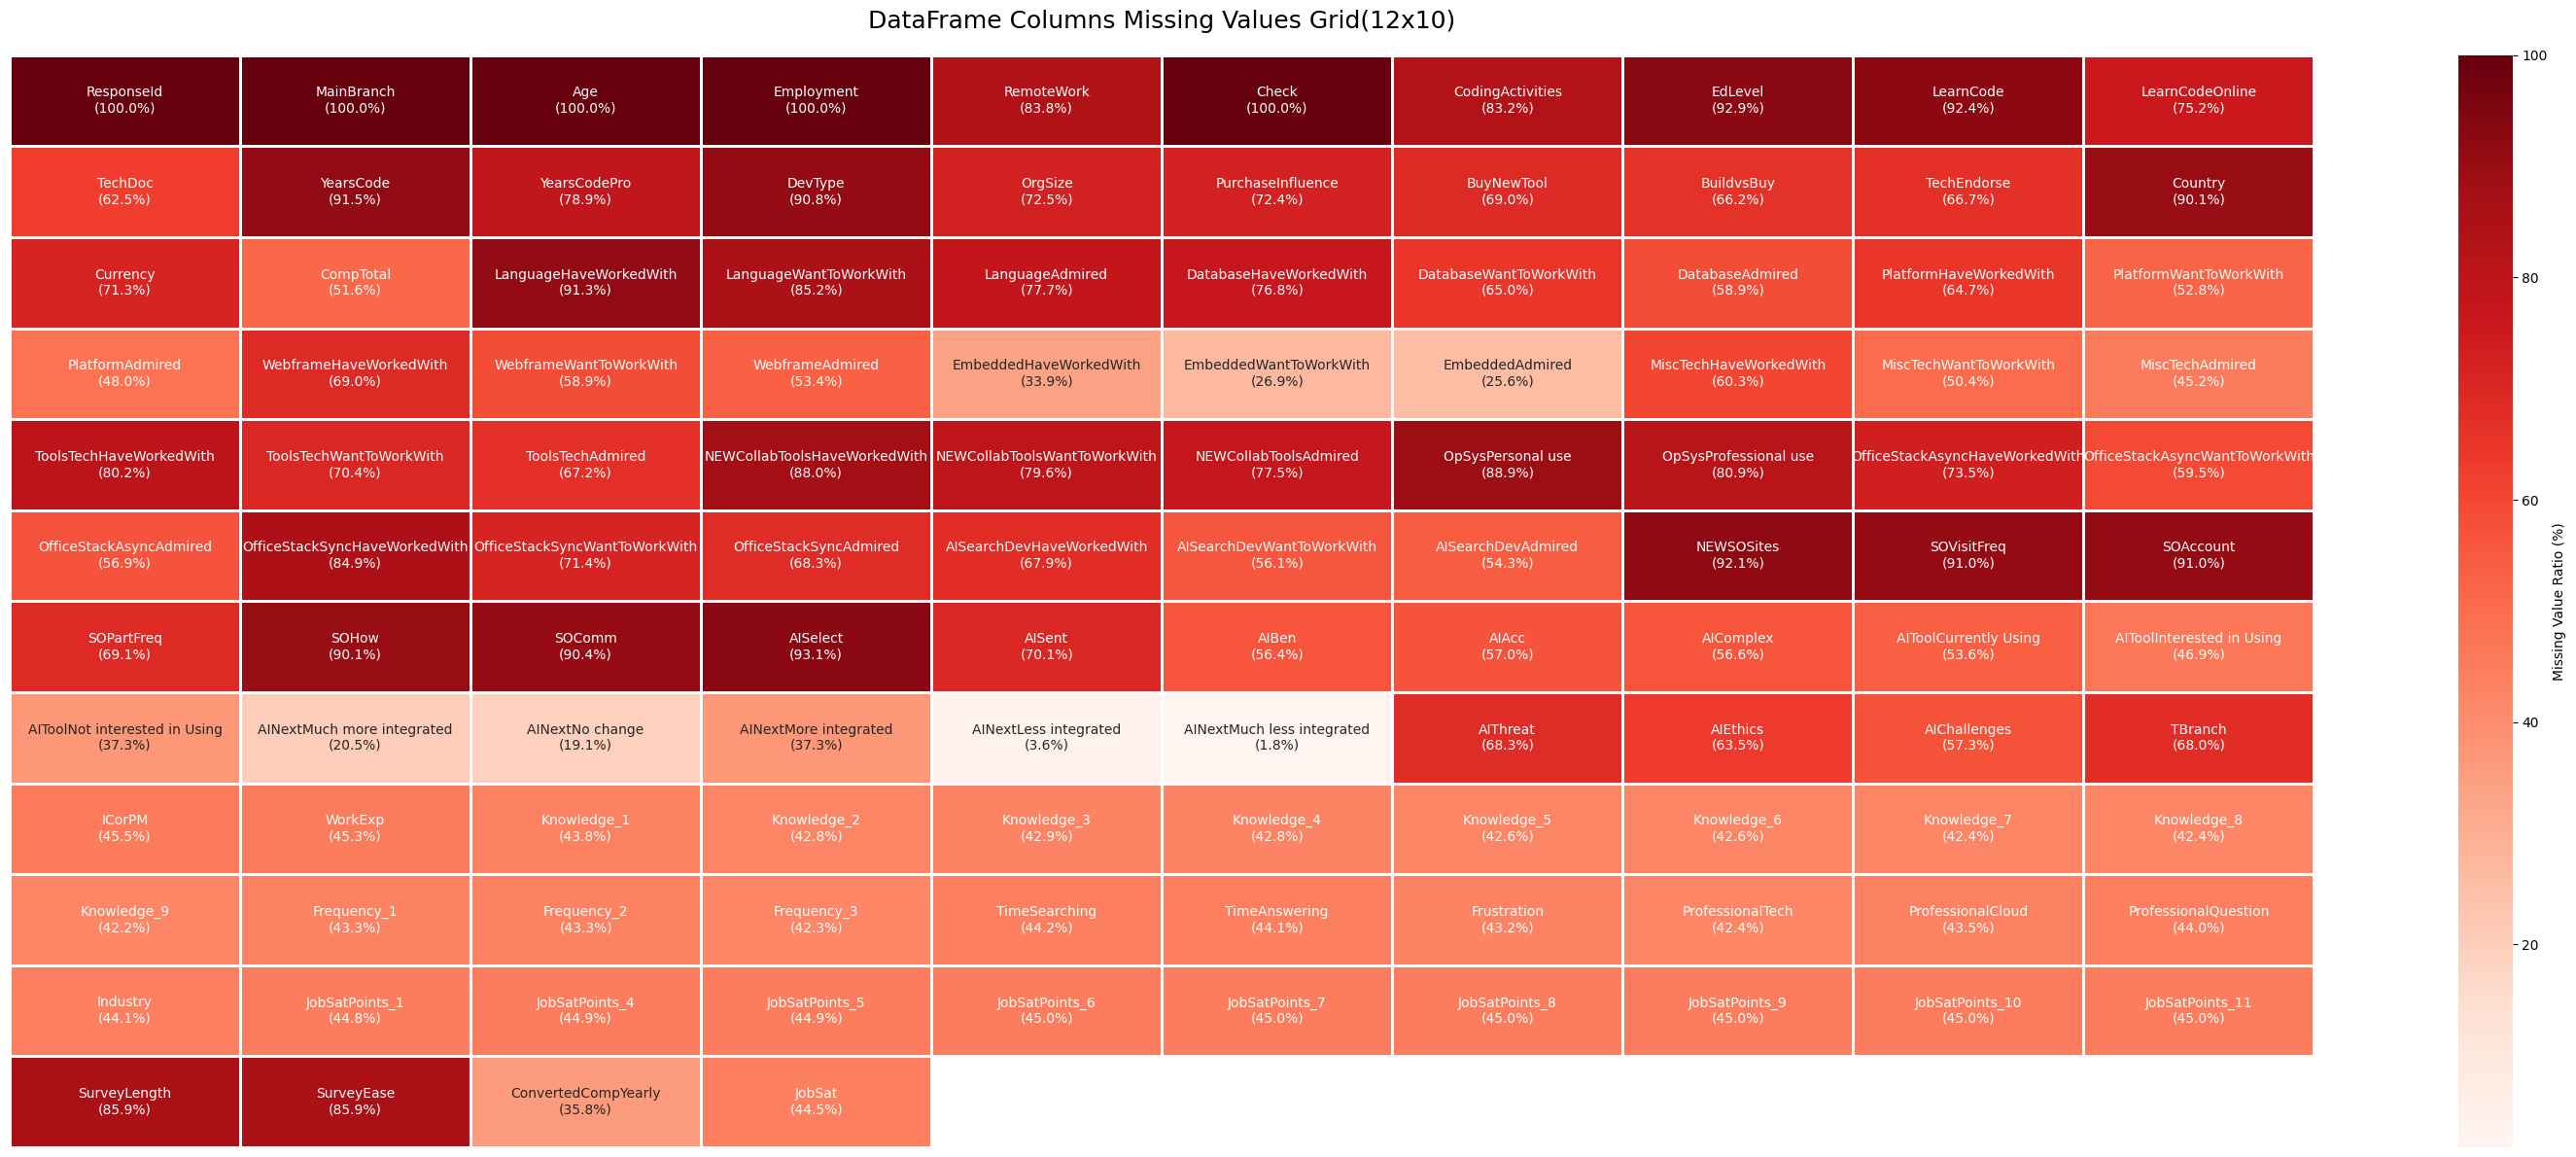

In [15]:
## Write your code here
%matplotlib inline
df_count = pd.DataFrame(df.count(),columns=['Count'])
missing_pct = df_count['Count']*100/df.shape[0]
n_rows, n_cols = 12,10
total_cells = n_rows * n_cols
values_pad = np.pad(missing_pct.values, (0, total_cells-len(missing_pct)), mode='constant', constant_values=np.nan)
grid_values = values_pad.reshape(n_rows, n_cols)
labels = []
for i in range(total_cells):
    if i < len(missing_pct):
        col = missing_pct.index[i]
        val = missing_pct.values[i]
        labels.append(f"{col}\n({val:.1f}%)")
    else:
        labels.append("")
grid_labels = np.array(labels).reshape(n_rows, n_cols)
plt.figure(figsize=(30,12))
sns.heatmap(grid_values,
            annot=grid_labels,
            fmt="",
            cmap="Reds",
            linewidth=1,
            linecolor="white",
            cbar_kws={'label': 'Missing Value Ratio (%)'}
            )
plt.title("DataFrame Columns Missing Values Grid(12x10)", fontsize=18,pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [10]:
## Write your code here
missed_rows = df.shape[0] - df['Employment'].count()
missed_rows

np.int64(0)

### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [12]:
## Write your code here
df['Employment'].value_counts().max()


np.int64(39046)

##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [16]:
## Write your code here
df['Employment'] = df['Employment'].fillna(df['Employment'].mode()[0])

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


65447   59307


C:\Users\IMST\AppData\Local\Temp\ipykernel_32788\382621897.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10.loc[10] = ["Etc",total_sum-t10sum]


<Figure size 1000x1000 with 0 Axes>

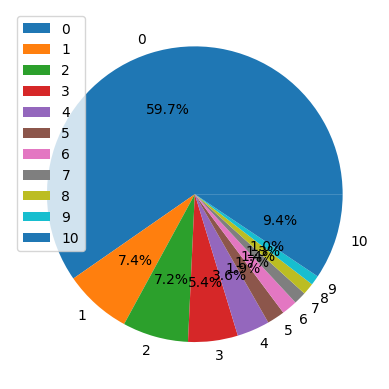

In [ ]:
## Write your code here
%matplotlib inline
freq = df['Employment'].value_counts().reset_index()
freq.sort_values(by='count',inplace=True,ascending=False)
top10=freq.iloc[0:10]
t10sum = top10['count'].sum()
total_sum = freq['count'].sum()
print(total_sum," ",t10sum)
top10.loc[10] = ["Etc",total_sum-t10sum]
plt.figure(figsize=(10,10))
top10.plot(kind='pie',y='count', autopct='%1.1f%%')
plt.ylabel('')
plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
